In [1]:
import scanpy as sc
import anndata as ad
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import median_abs_deviation
import numpy as np
import os
import re
import warnings
from numba.core.errors import NumbaDeprecationWarning
import urllib.request
from pathlib import Path
import celltypist
from celltypist import models
from scipy.sparse import csr_matrix
import harmonypy as hm

KeyboardInterrupt: 

In [2]:
# Load in data

adata = sc.read("/rds/general/user/ztb25/home/PBMC_datasets/integrated_adata_scvi_corrected_matrix.h5ad")

In [3]:
# load in full adata for scANVI latent (didn't write to adata_scvi by accident)
adata_full = sc.read(
    "/rds/general/user/ztb25/home/PBMC_datasets/integrated_adata.h5ad",
    backed="r",                    # ← loads obs/obsm but keeps the matrix on disk
)
adata.obsm["X_scANVI"] = adata_full.obsm["X_scANVI"].copy()
adata_full.file.close()            # explicit close before deleting
del adata_full

In [4]:
adata

AnnData object with n_obs × n_vars = 880872 × 2000
    obs: 'age', 'gender', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'celltypist_cell_label_coarse', 'celltypist_conf_score_coarse', 'celltypist_cell_label_fine', 'celltypist_conf_score_fine', 'dataset', 'sample_combined', '_scvi_batch', '_scvi_labels'
    var: 'feature_types', 'mt', 'gene_symbols', 'genome', 'gene_versions', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'celltypist_cell_label_coarse_colors', 'celltypist_cell_label_fine_colors', 'dataset_colors', 'hvg', 'neighbors', 'pca', 'sample_combined_colors', 'scVI', 'umap'
    obsm: 'X_pca', 'X_scVI', 'X_umap', 'X_umap_unintegrated', 'X_scANVI'
    varm: 'PCs'
    layers: 'counts', 'log1p_norm', 'scanvi_corrected'
    obsp: 'conne

In [5]:
# set scanvi corrected matrix as active layer

adata.X = adata.layers["scanvi_corrected"]

In [6]:
# log transform the data (corrected matrix is already normalized)

sc.pp.log1p(adata)

In [7]:
# download celltypist models for immune cells 
models.download_models(
    force_update=True, model=["Immune_All_Low.pkl", "Immune_All_High.pkl"]
)

model_low = models.Model.load(model="Immune_All_Low.pkl") # finer annotation level
model_high = models.Model.load(model="Immune_All_High.pkl") # coarser annotation level

📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json
📚 Total models in list: 61
📂 Storing models in /rds/general/user/ztb25/home/.celltypist/data/models
💾 Total models to download: 2
💾 Downloading model [1/2]: Immune_All_Low.pkl
💾 Downloading model [2/2]: Immune_All_High.pkl


In [8]:
# run high model 

predictions_high = celltypist.annotate(
    adata, model=model_high, majority_voting=True 
)

predictions_high_adata = predictions_high.to_adata() # transform predictions to adata for full output

# copy results into original AnnData obj
adata.obs["celltypist_cell_label_coarse_new"] = predictions_high_adata.obs.loc[
    adata.obs.index, "majority_voting"
]
adata.obs["celltypist_conf_score_coarse_new"] = predictions_high_adata.obs.loc[
    adata.obs.index, "conf_score"
]

🔬 Input data has 880872 cells and 2000 genes
🔗 Matching reference genes in the model
🧬 1498 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 30
🗳️ Majority voting the predictions
✅ Majority voting done!


In [9]:
# run low (fine) model
predictions_low = celltypist.annotate(
    adata, model=model_low, majority_voting=True
)
predictions_low_adata = predictions_low.to_adata()

adata.obs["celltypist_cell_label_fine_new"] = predictions_low_adata.obs.loc[
    adata.obs.index, "majority_voting"
]
adata.obs["celltypist_conf_score_fine_new"] = predictions_low_adata.obs.loc[
    adata.obs.index, "conf_score"
]

🔬 Input data has 880872 cells and 2000 genes
🔗 Matching reference genes in the model
🧬 1498 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 30
🗳️ Majority voting the predictions
✅ Majority voting done!


In [10]:
# quick distribution + confidence check
print("Coarse label counts:")
print(adata.obs["celltypist_cell_label_coarse_new"].value_counts().head(20))
print(f"\nMean coarse confidence: {adata.obs['celltypist_conf_score_coarse_new'].mean():.3f}")
print(f"Mean fine confidence:   {adata.obs['celltypist_conf_score_fine_new'].mean():.3f}")
print(f"Low-confidence cells (<0.5): "
      f"{(adata.obs['celltypist_conf_score_coarse_new'] < 0.5).sum()} / {adata.n_obs}")

Coarse label counts:
ILC                         308518
Monocytes                   271391
Mono-mac                    148742
Cycling cells                70229
B cells                      68833
pDC                           6160
DC                            4976
Megakaryocytes/platelets      1440
ETP                            583
Name: celltypist_cell_label_coarse_new, dtype: int64

Mean coarse confidence: 0.739
Mean fine confidence:   0.802
Low-confidence cells (<0.5): 251337 / 880872


In [11]:
# only run if no UMAP present (right now, fixed integration code for reruns)
if "X_umap_scANVI" not in adata.obsm:
    sc.pp.neighbors(adata, use_rep="X_scANVI")
    sc.tl.umap(adata)
    adata.obsm["X_umap_scANVI"] = adata.obsm["X_umap"].copy()


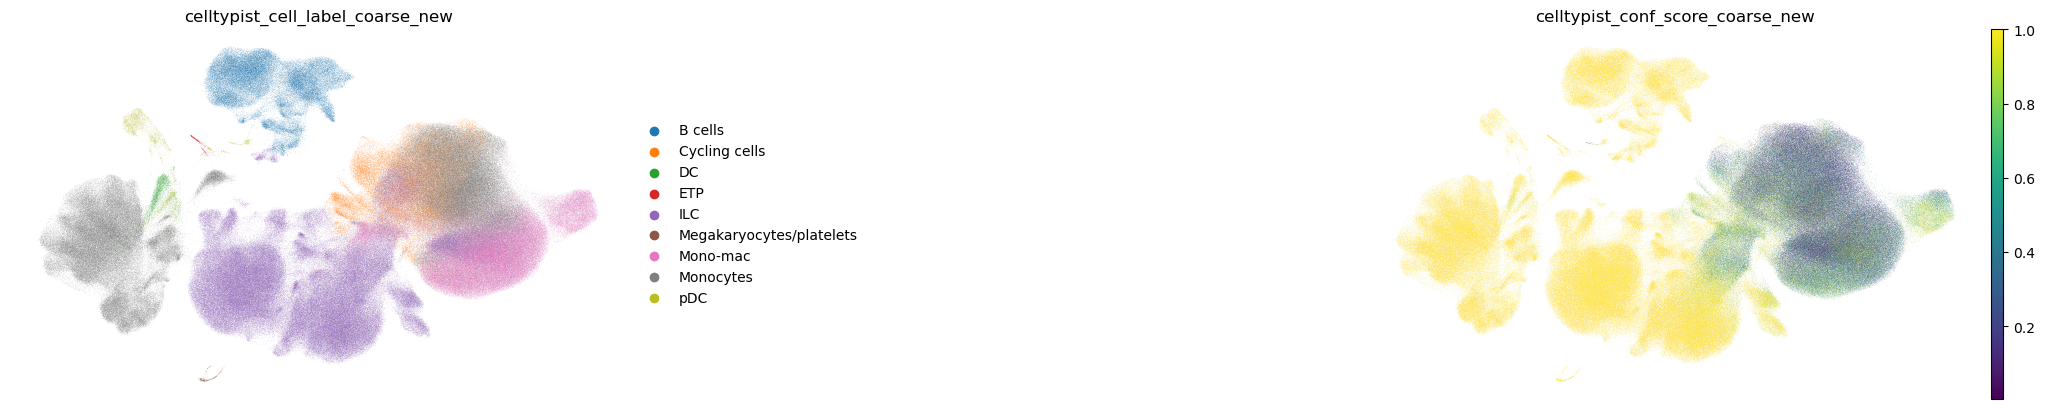

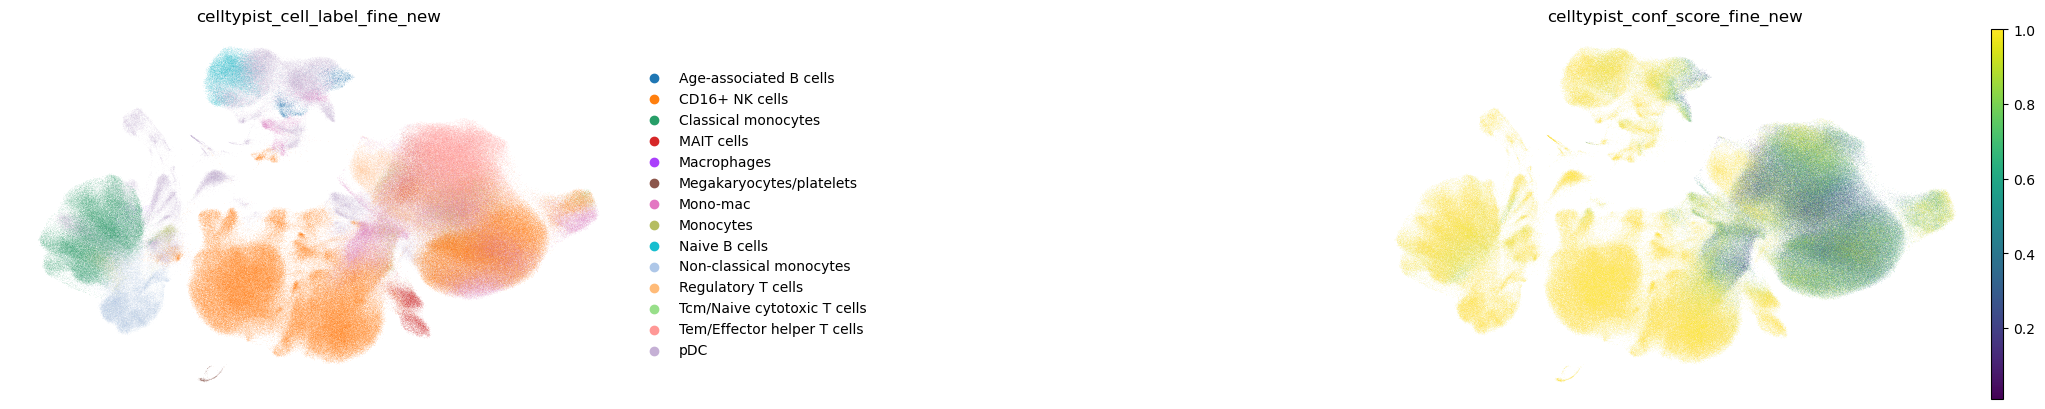

In [12]:
# pick whichever UMAP you have — prefer scANVI's
basis = "X_umap_scANVI" if "X_umap_scANVI" in adata.obsm else "X_umap"

sc.pl.embedding(
    adata, basis=basis,
    color=["celltypist_cell_label_coarse_new", "celltypist_conf_score_coarse_new"],
    frameon=False, sort_order=False, wspace=1,
)

sc.pl.embedding(
    adata, basis=basis,
    color=["celltypist_cell_label_fine_new", "celltypist_conf_score_fine_new"],
    frameon=False, sort_order=False, wspace=1,
)

In [ ]:
# rename old labels (carried over from per-dataset CellTypist) to compare
# the per-dataset originals should still be in obs under their original names



In [14]:
adata

AnnData object with n_obs × n_vars = 880872 × 2000
    obs: 'age', 'gender', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'celltypist_cell_label_coarse', 'celltypist_conf_score_coarse', 'celltypist_cell_label_fine', 'celltypist_conf_score_fine', 'dataset', 'sample_combined', '_scvi_batch', '_scvi_labels', 'predicted_labels', 'majority_voting', 'conf_score', 'celltypist_cell_label_coarse_new', 'celltypist_conf_score_coarse_new', 'over_clustering', 'celltypist_cell_label_fine_new', 'celltypist_conf_score_fine_new'
    var: 'feature_types', 'mt', 'gene_symbols', 'genome', 'gene_versions', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'celltypist_cell_label_coarse_colors', 'celltypist_cell_label_fine_colors', 'dataset_colors', 'hvg', 'neighbor

celltypist_cell_label_coarse_new  B cells  Cycling cells    DC   ETP   ILC  \
celltypist_cell_label_coarse                                                 
B cells                              0.98           0.00  0.00  0.00  0.02   
DC                                   0.00           0.00  0.69  0.00  0.00   
ETP                                  0.00           0.00  0.00  0.99  0.00   
HSC/MPP                              0.00           0.00  0.00  0.95  0.04   
ILC                                  0.00           0.00  0.00  0.00  1.00   
Megakaryocyte precursor              0.00           1.00  0.00  0.00  0.00   
Megakaryocytes/platelets             0.01           0.02  0.00  0.00  0.02   
Monocytes                            0.00           0.00  0.00  0.00  0.00   
Plasma cells                         0.04           0.02  0.00  0.00  0.00   
T cells                              0.00           0.13  0.00  0.00  0.32   
pDC                                  0.00           0.00  0.00  

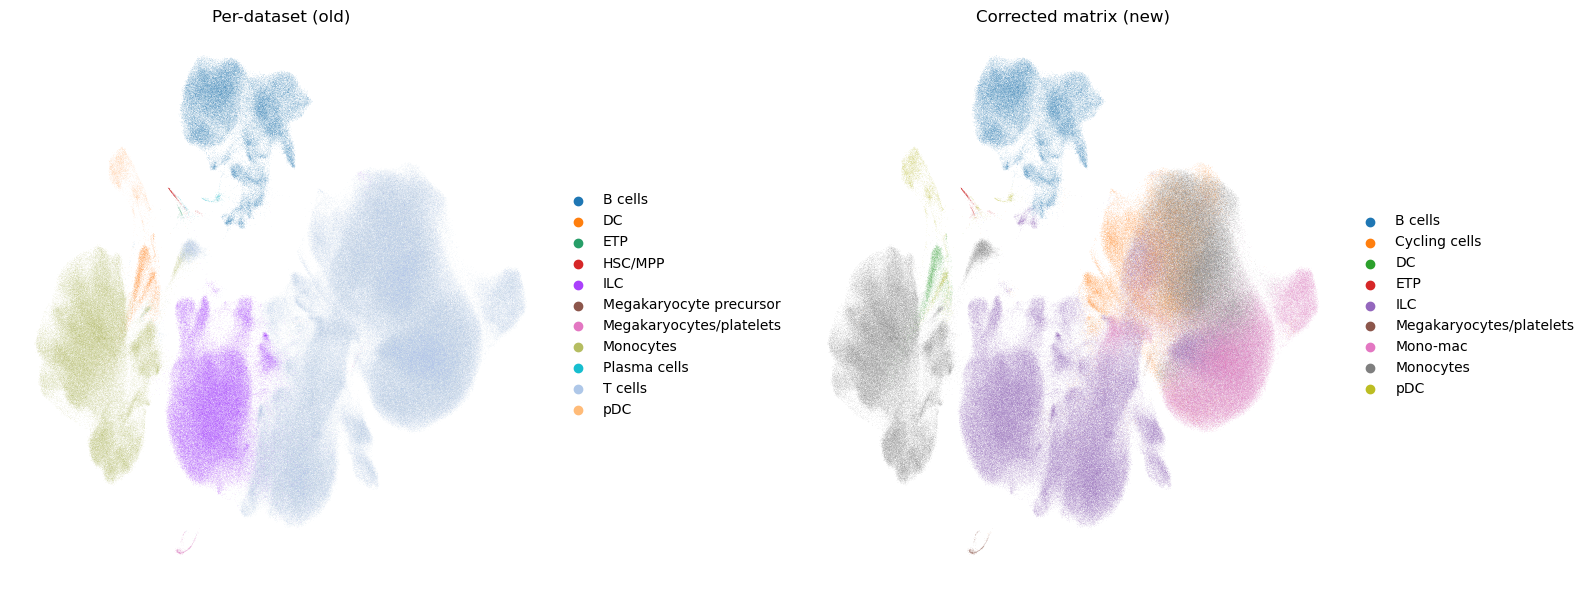

In [23]:
# how much does corrected-matrix annotation agree with per-dataset annotation?

# crosstab: old coarse label vs new coarse label
old_col = "celltypist_cell_label_coarse"
new_col = "celltypist_cell_label_coarse_new"

ct = pd.crosstab(
    adata.obs[old_col],
    adata.obs[new_col],
    normalize="index"
)
print(ct.round(2))

# overall agreement rate
agree = (adata.obs[old_col].astype(str) ==
         adata.obs[new_col].astype(str)).mean()
print(f"\nOverall agreement: {agree:.1%}")

# plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sc.pl.embedding(adata, basis=basis, color=old_col,
                ax=axes[0], show=False, frameon=False, title="Per-dataset (old)")
sc.pl.embedding(adata, basis=basis, color=new_col,
                ax=axes[1], show=False, frameon=False, title="Corrected matrix (new)")
plt.tight_layout()
plt.show()

celltypist_cell_label_fine_new  Age-associated B cells  CD16+ NK cells  \
celltypist_cell_label_fine                                               
Age-associated B cells                            0.75            0.00   
CD16+ NK cells                                    0.00            1.00   
Classical monocytes                               0.00            0.02   
DC1                                               0.00            0.00   
DC2                                               0.00            0.00   
ETP                                               0.00            0.00   
HSC/MPP                                           0.00            0.04   
ILC3                                              0.00            0.09   
MAIT cells                                        0.00            0.16   
Megakaryocyte precursor                           0.00            0.00   
Megakaryocytes/platelets                          0.00            0.24   
Memory B cells                        

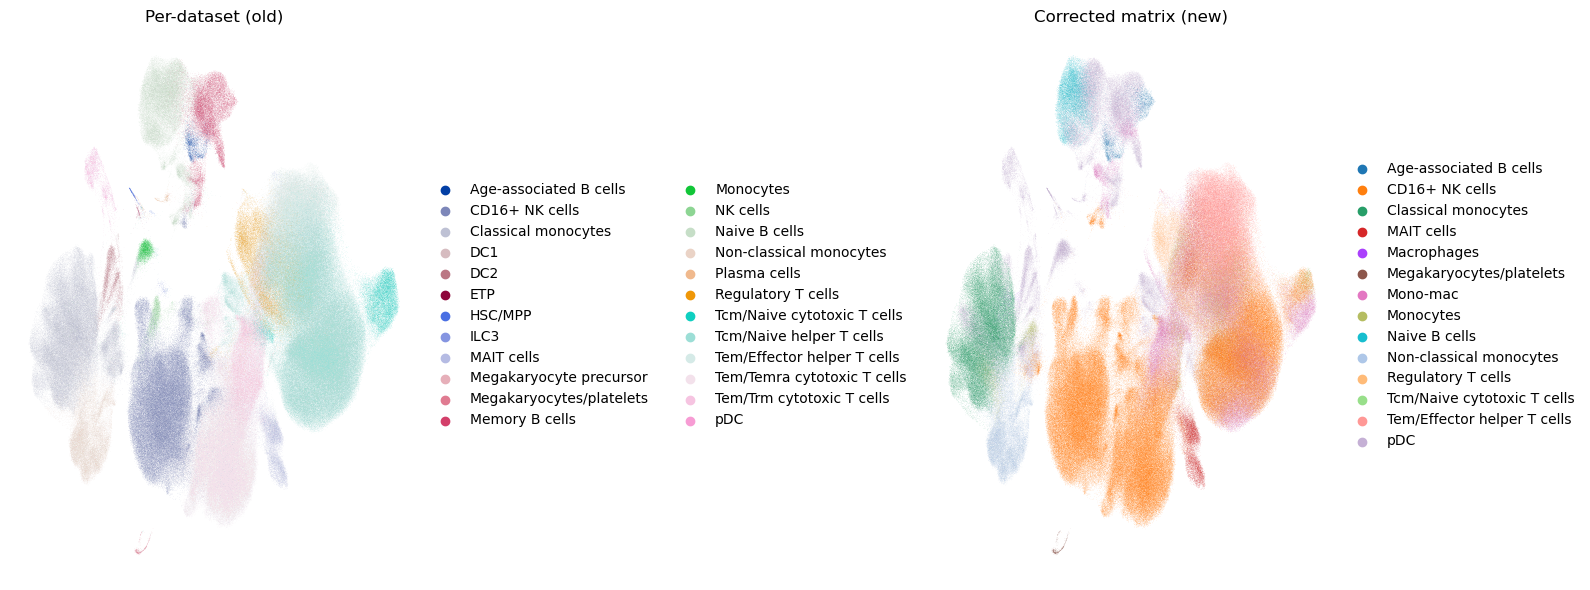

In [22]:
# do again for fine labels

old_col = "celltypist_cell_label_fine"
new_col = "celltypist_cell_label_fine_new"

ct = pd.crosstab(
    adata.obs[old_col],
    adata.obs[new_col],
    normalize="index"
)
print(ct.round(2))

# overall agreement rate
agree = (adata.obs[old_col].astype(str) ==
         adata.obs[new_col].astype(str)).mean()
print(f"\nOverall agreement: {agree:.1%}")

# plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sc.pl.embedding(adata, basis=basis, color=old_col,
                ax=axes[0], show=False, frameon=False, title="Per-dataset (old)")
sc.pl.embedding(adata, basis=basis, color=new_col,
                ax=axes[1], show=False, frameon=False, title="Corrected matrix (new)")
plt.tight_layout()
plt.show()

In [21]:
adata.write(
    "/rds/general/user/ztb25/home/PBMC_datasets/integrated_adata_reannotated.h5ad"
)

In [26]:
# trying scvi differential expression tool

adata.obs["celltypist_cell_label_fine"].value_counts()


Tcm/Naive helper T cells       276082
CD16+ NK cells                 130968
Classical monocytes            100198
Tem/Temra cytotoxic T cells     95091
Tem/Effector helper T cells     61507
Tem/Trm cytotoxic T cells       46223
Naive B cells                   42217
Non-classical monocytes         27627
Memory B cells                  24084
Regulatory T cells              23014
Tcm/Naive cytotoxic T cells     17502
MAIT cells                      13022
DC2                              6313
NK cells                         4075
pDC                              3805
Monocytes                        3687
Age-associated B cells           3124
Megakaryocytes/platelets          710
Plasma cells                      471
HSC/MPP                           428
ILC3                              405
ETP                               172
DC1                               131
Megakaryocyte precursor            16
Name: celltypist_cell_label_fine, dtype: int64

In [30]:
cell_type_1 = "Classical monocytes"
cell_idx1 = adata.obs["celltypist_cell_label_fine"] == cell_type_1
print(sum(cell_idx1), "cells of type", cell_type_1)

cell_type_2 = "Tcm/Naive helper T cells"
cell_idx2 = adata.obs["celltypist_cell_label_fine"] == cell_type_2
print(sum(cell_idx2), "cells of type", cell_type_2)


100198 cells of type Classical monocytes
276082 cells of type Tcm/Naive helper T cells


In [33]:
import scvi
model = scvi.model.SCVI(
    adata, gene_likelihood="nb"
)  # We use Negative Binomial count likelihoods, following Boyeau et al., 2023.
model.train(
    check_val_every_n_epoch=1,
    max_epochs=400,
    early_stopping=True,
    early_stopping_patience=20,
    early_stopping_monitor="elbo_validation",
)

AttributeError: module 'jax' has no attribute 'Device'

In [31]:
de_change = model.differential_expression(idx1=cell_idx1, idx2=cell_idx2, mode="change")
de_change

NameError: name 'model' is not defined

In [ ]:
# to justify going with original annotations